# 01 — Downloading and validating the open credit-default dataset

This notebook downloaded the public UCI credit-default dataset, standardized the schema, checked data quality, and saved the cleaned base table. The raw data was not committed to the repository; it was being downloaded when the notebook was executed.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from project_package.config import ensure_project_dirs, PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, TARGET
from project_package.plotting import save_figure
from project_package.reporting import save_table

ensure_project_dirs()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

from project_package.data import download_uci_default_dataset, load_raw_uci_default, clean_credit_default_data, save_processed_base
from project_package.validation import run_base_validations, validations_to_frame

## Downloading the source file

The dataset was being downloaded into `data/raw/`.

In [3]:
raw_path = download_uci_default_dataset(force=False)
raw_path

WindowsPath('C:/Users/Peter/Documents/projects/SHORT PROJECTS/ml-projects/credit-scoring-unbanked-mobile-money/data/raw/default_of_credit_card_clients.xls')

In [ ]:
#!pip install "xlrd>=2.0.1"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Loading and cleaning

The original UCI column names were converted into clearer variable names. Categorical codes were also mapped to readable labels, while unusual education and marriage codes were grouped as `other` rather than discarded.

In [6]:
raw_df = load_raw_uci_default(raw_path)
clean_df = clean_credit_default_data(raw_df)
print(clean_df.shape)
clean_df.head()

(30000, 24)


,credit_limit,sex,education,marriage,age,pay_status_sep,pay_status_aug,pay_status_jul,pay_status_jun,pay_status_may,pay_status_apr,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr,default_next_month
0,20000,female,university,married,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,female,university,single,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,female,university,single,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,female,university,married,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,male,university,married,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Schema and target validation

Basic validation checks were being run before the dataset was saved. These checks created a report-ready validation table.

In [7]:
validation_results = run_base_validations(clean_df)
validation_table = validations_to_frame(validation_results)
save_table(validation_table, "01_validation_results.csv")
validation_table

,check,passed,errors,warnings
0,required_columns,True,,
1,binary_target,True,,
2,duplicate_rows,True,,Found 35 duplicated rows.


## Data-quality summary

A compact data-quality table was saved for the final report. The target prevalence was included because class imbalance affected model selection and metric interpretation.

In [8]:
quality_summary = pd.DataFrame({
    "n_rows": [len(clean_df)],
    "n_columns": [clean_df.shape[1]],
    "target_positive_rate": [clean_df[TARGET].mean()],
    "duplicate_rows": [clean_df.duplicated().sum()],
    "total_missing_values": [int(clean_df.isna().sum().sum())],
})
save_table(quality_summary, "01_data_quality_summary.csv")
processed_path = save_processed_base(clean_df)
print(f"Saved cleaned base dataset to: {processed_path}")
quality_summary

Saved cleaned base dataset to: C:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\credit-scoring-unbanked-mobile-money\data\processed\credit_default_base.csv


,n_rows,n_columns,target_positive_rate,duplicate_rows,total_missing_values
0,30000,24,0.2212,35,0


## Missingness figure

The figure was saved before display, even when no missingness was detected.

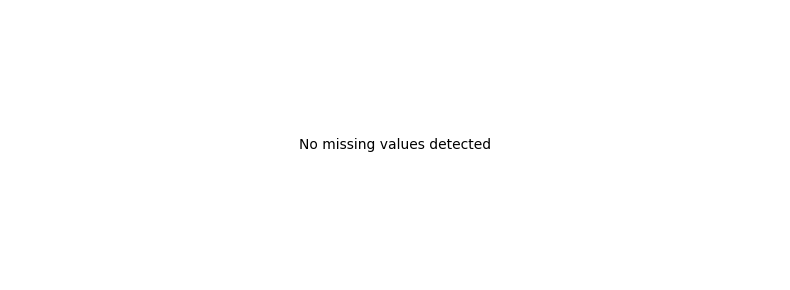

In [9]:
from project_package.plotting import plot_missingness
fig = plot_missingness(clean_df)
save_figure(fig, "01_missingness_by_variable.png")
plt.show()